In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline


In [2]:
df = pd.read_csv('EasyVisa.csv')

In [3]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [4]:
df.shape

(25480, 12)

In [5]:
df.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


In [7]:
df.isnull().sum()

case_id                  0
continent                0
education_of_employee    0
has_job_experience       0
requires_job_training    0
no_of_employees          0
yr_of_estab              0
region_of_employment     0
prevailing_wage          0
unit_of_wage             0
full_time_position       0
case_status              0
dtype: int64

In [8]:
num_features = [feature for feature in df.columns if df[feature].dtype!= 'O']
cat_features = [feature for feature in df.columns if df[feature].dtype == 'O']

print("We have {} numerical features: {}".format(len(num_features),num_features))
print("We have {} categorical features: {}".format(len(cat_features),cat_features))


We have 3 numerical features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']
We have 9 categorical features: ['case_id', 'continent', 'education_of_employee', 'has_job_experience', 'requires_job_training', 'region_of_employment', 'unit_of_wage', 'full_time_position', 'case_status']


In [9]:
## it is for identify useful columns
for col in cat_features:
    print(df[col].value_counts(normalize=True)*100)
    print('-----------------')

case_id
EZYV01       0.003925
EZYV16995    0.003925
EZYV16993    0.003925
EZYV16992    0.003925
EZYV16991    0.003925
               ...   
EZYV8492     0.003925
EZYV8491     0.003925
EZYV8490     0.003925
EZYV8489     0.003925
EZYV25480    0.003925
Name: proportion, Length: 25480, dtype: float64
-----------------
continent
Asia             66.173469
Europe           14.646782
North America    12.919937
South America     3.343799
Africa            2.162480
Oceania           0.753532
Name: proportion, dtype: float64
-----------------
education_of_employee
Bachelor's     40.164835
Master's       37.810047
High School    13.422292
Doctorate       8.602826
Name: proportion, dtype: float64
-----------------
has_job_experience
Y    58.092622
N    41.907378
Name: proportion, dtype: float64
-----------------
requires_job_training
N    88.402669
Y    11.597331
Name: proportion, dtype: float64
-----------------
region_of_employment
Northeast    28.237834
South        27.539246
West         25.84

### Insights
   * case_id have unique value values for each columns which can be dropped as it has no importance
   + continent columns highly baised towards asia. hence we can combine other categories to form a single category
   - unit_of_wage seems to be an important column as most of them are already contracts

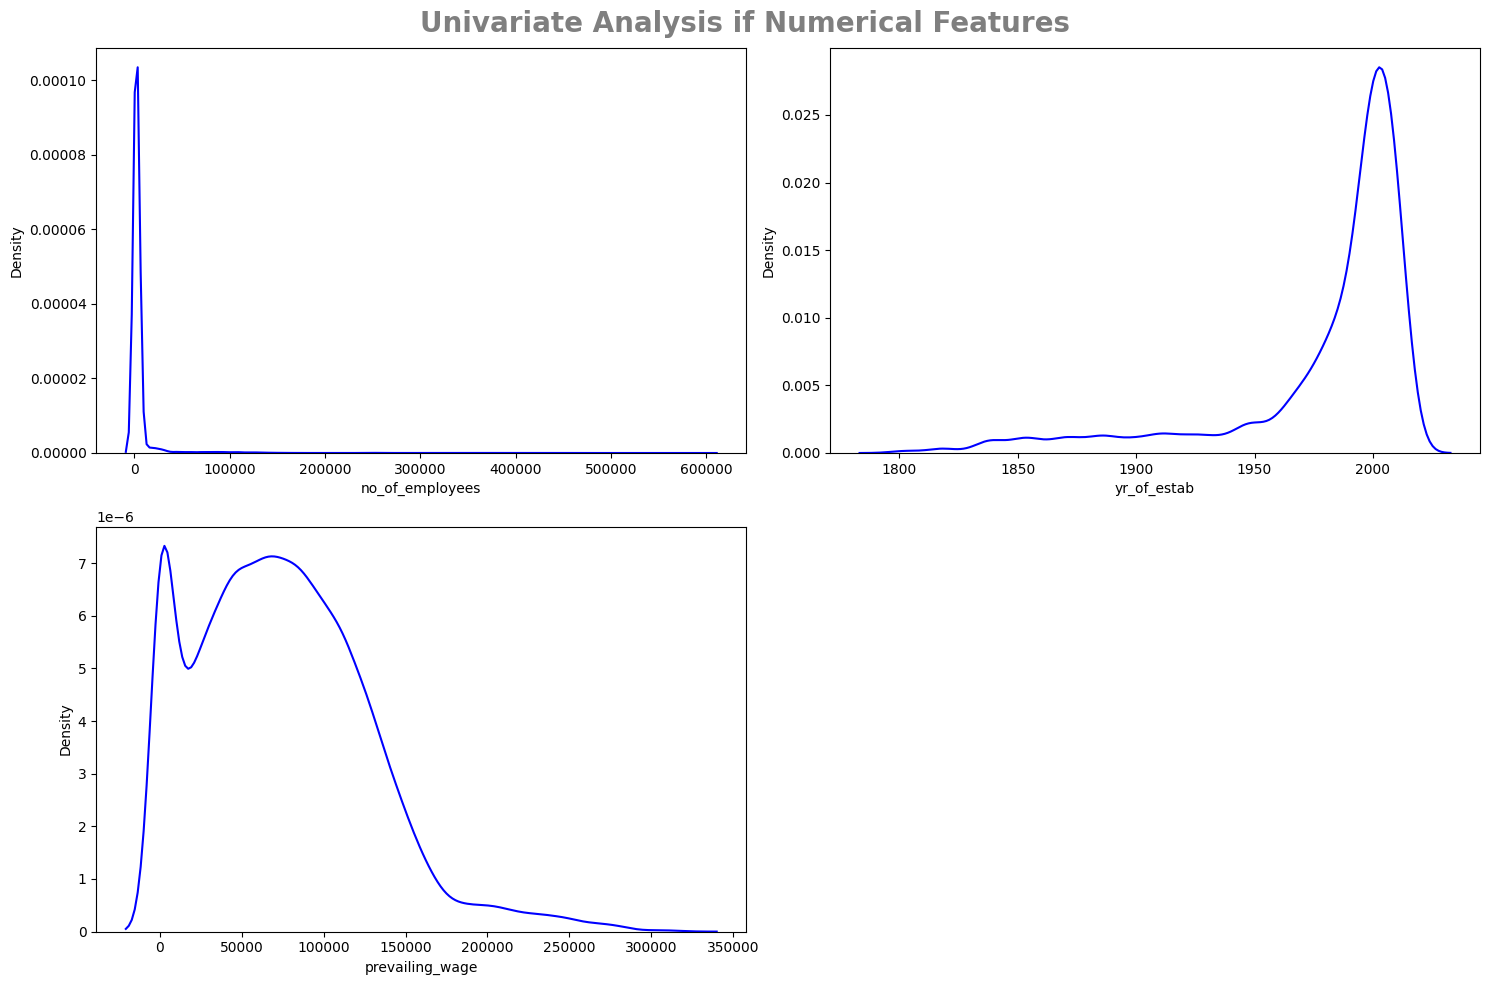

In [10]:
plt.figure(figsize=(15,10))
plt.suptitle("Univariate Analysis if Numerical Features", fontsize=20, fontweight='bold',alpha=0.5)

for i in range(0, len(num_features)):
    plt.subplot(2,2, i+1)
    sns.kdeplot(x=df[num_features[i]], color='blue')
    plt.xlabel(num_features[i])
    plt.tight_layout()

### Insights

* no_of_employees column looks more skewed but it may be because of outliers
*  yr_of_estab is a discrete feature
* privailing_wage is a right-skewed distribution

In [11]:
cat_features.remove('case_id')

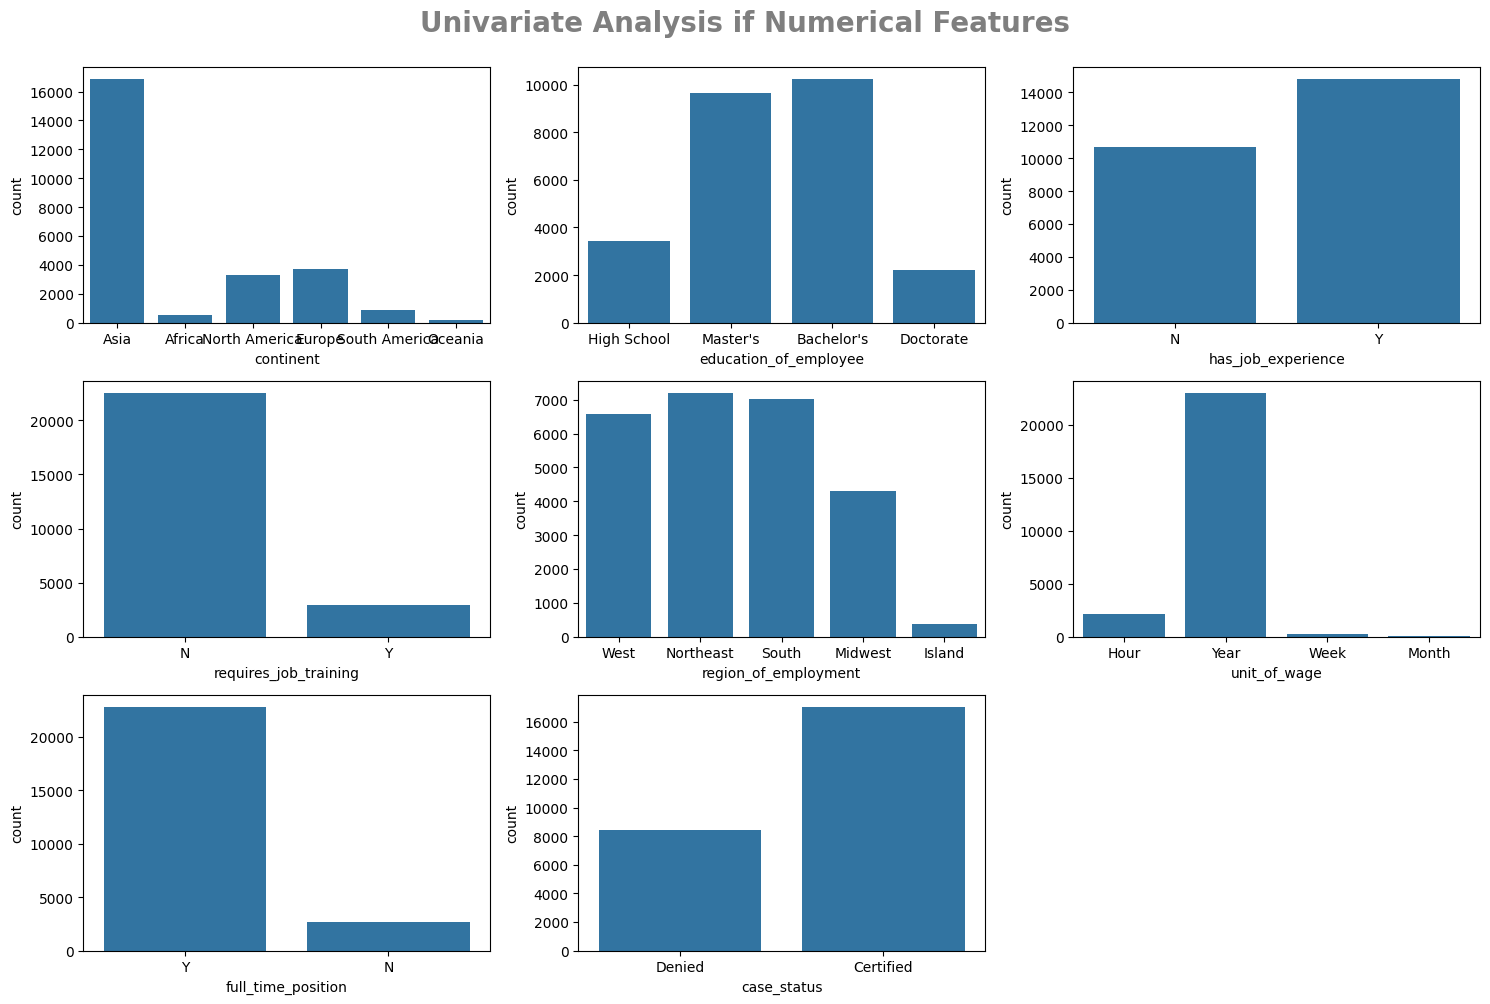

In [12]:

plt.figure(figsize=(15,10))
plt.suptitle("Univariate Analysis if Numerical Features", fontsize=20, fontweight='bold',alpha=0.5,y=1.)
for i in range(0,len(cat_features)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[cat_features[i]])
    plt.xlabel(cat_features[i])
    plt.tight_layout()

### It is imbalanced dataset

# Multivariate Analysis

In [13]:
discrete_feature = [feature for feature in num_features if len(df[feature].unique())<=25]

continuous_feature = [feature for feature in num_features if len(df[feature].unique()) > 25]

print("We have {} discrete features: {}".format(len(discrete_feature),discrete_feature))
print("We have {} continuous features: {}".format(len(continuous_feature),continuous_feature))


We have 0 discrete features: []
We have 3 continuous features: ['no_of_employees', 'yr_of_estab', 'prevailing_wage']


In [14]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [15]:
from scipy.stats import chi2_contingency
chi2_test = []
for feature in cat_features:
    if chi2_contingency(pd.crosstab(df['case_status'], df[feature]))[1] < 0.05:
        chi2_test.append('Reject NULL Hypothesie')
    else:
        chi2_test.append('Failed to Reject NULL Hypothesie')
result = pd.DataFrame(data=[cat_features,chi2_test]).T
result.columns = ['Columns', 'Hypothesis Result']
result


,Columns,Hypothesis Result
0,continent,Reject NULL Hypothesie
1,education_of_employee,Reject NULL Hypothesie
2,has_job_experience,Reject NULL Hypothesie
3,requires_job_training,Failed to Reject NULL Hypothesie
4,region_of_employment,Reject NULL Hypothesie
5,unit_of_wage,Reject NULL Hypothesie
6,full_time_position,Reject NULL Hypothesie
7,case_status,Reject NULL Hypothesie


#### Here requires_job_training fails to Reject NULL Hypothesis which means it doesn't correlate with target column

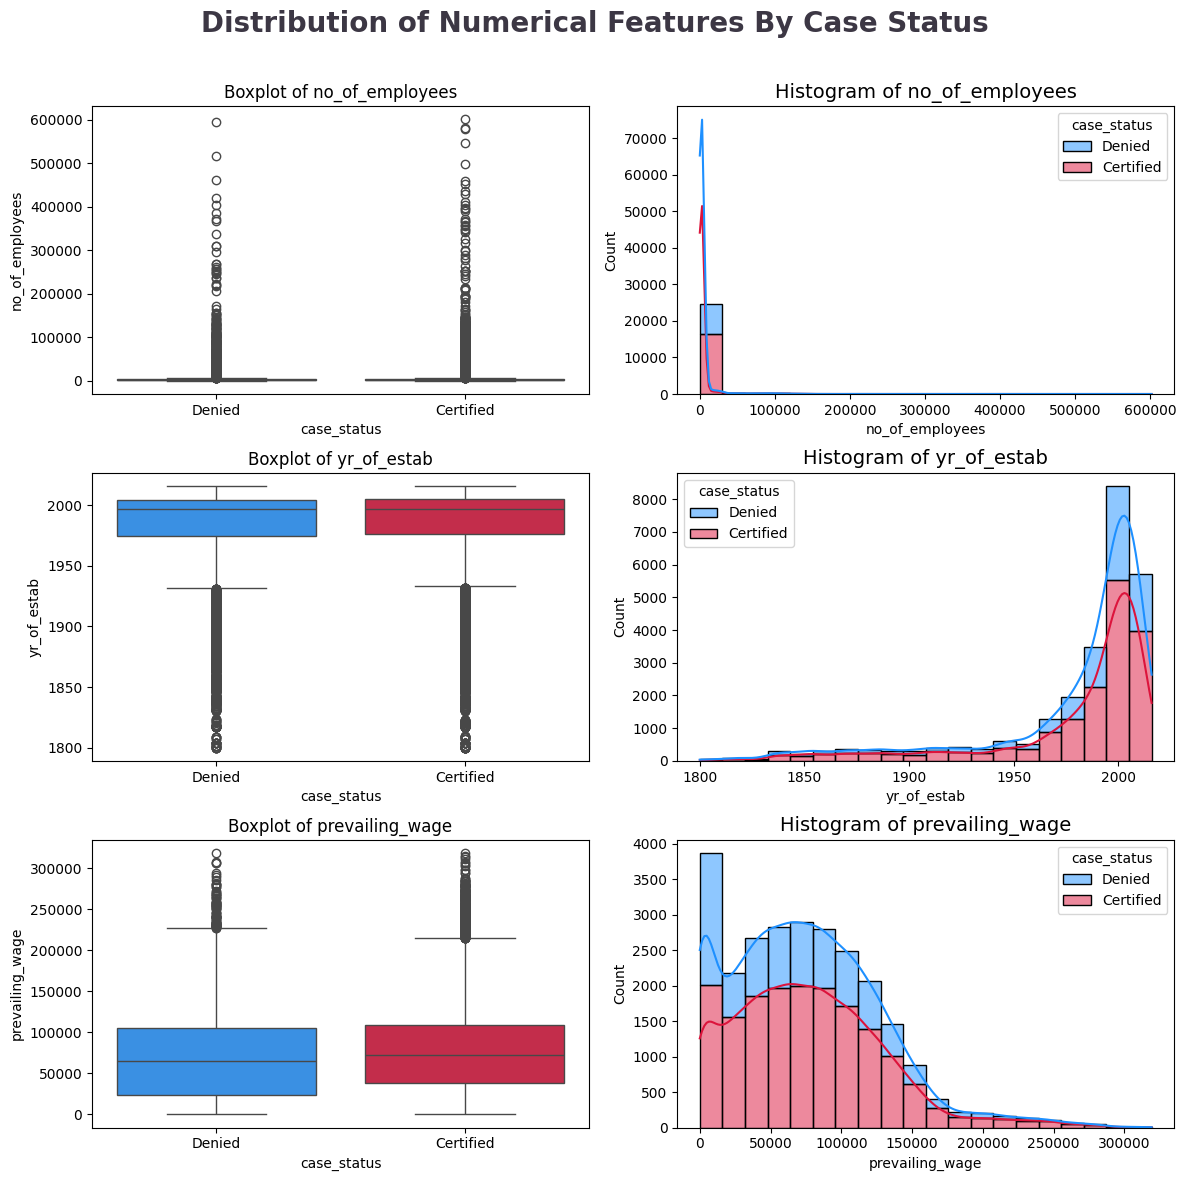

In [16]:
clr1 = ['#1E90FF','#DC143C']
fig,ax = plt.subplots(3,2, figsize=(12,12))
fig.suptitle('Distribution of Numerical Features By Case Status',color='#3C3744',fontsize=20,fontweight='bold',ha='center')
for i,col in enumerate(continuous_feature):
    sns.boxplot(data=df,x='case_status',y=col,palette=clr1,ax=ax[i,0])
    ax[i,0].set_title(f'Boxplot of {col}',fontsize=12)
    sns.histplot(data=df,x=col,hue='case_status',bins=20,kde=True,multiple='stack',palette=clr1,ax=ax[i,1])
    ax[i,1].set_title(f'Histogram of {col}',fontsize=14)
fig.tight_layout()
fig.subplots_adjust(top=0.90)

### there is outliers

### Visualize the target features

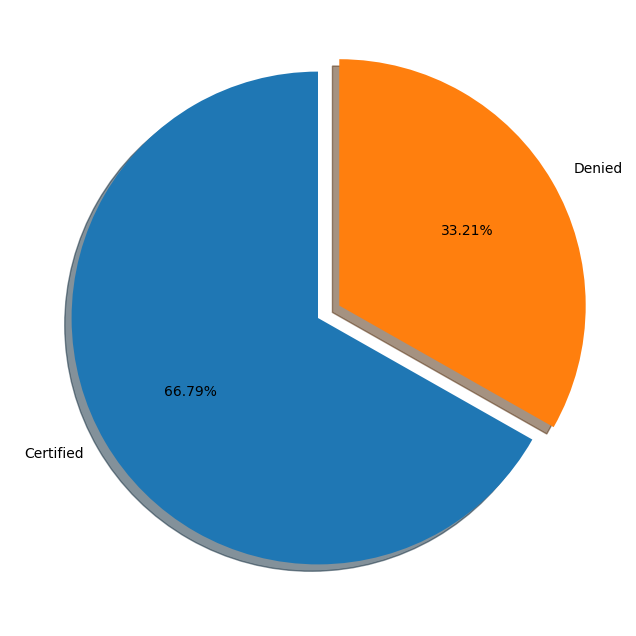

In [17]:
percentage = df.case_status.value_counts(normalize=True)*100
labels = ['Certified','Denied']
fig,ax = plt.subplots(figsize=(15,8))
explode = (0,0.1)
ax.pie(percentage,labels=labels,startangle=90,autopct='%1.2f%%',explode=explode,shadow=True)
plt.show()

#### It is a imbalanced dataset

In [18]:
df.groupby('continent')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
continent     case_status            
Africa        Certified     72.050817
              Denied        27.949183
Asia          Certified     65.310480
              Denied        34.689520
Europe        Certified     79.233655
              Denied        20.766345
North America Certified     61.877278
              Denied        38.122722
Oceania       Certified     63.541667
              Denied        36.458333
South America Certified     57.863850
              Denied        42.136150

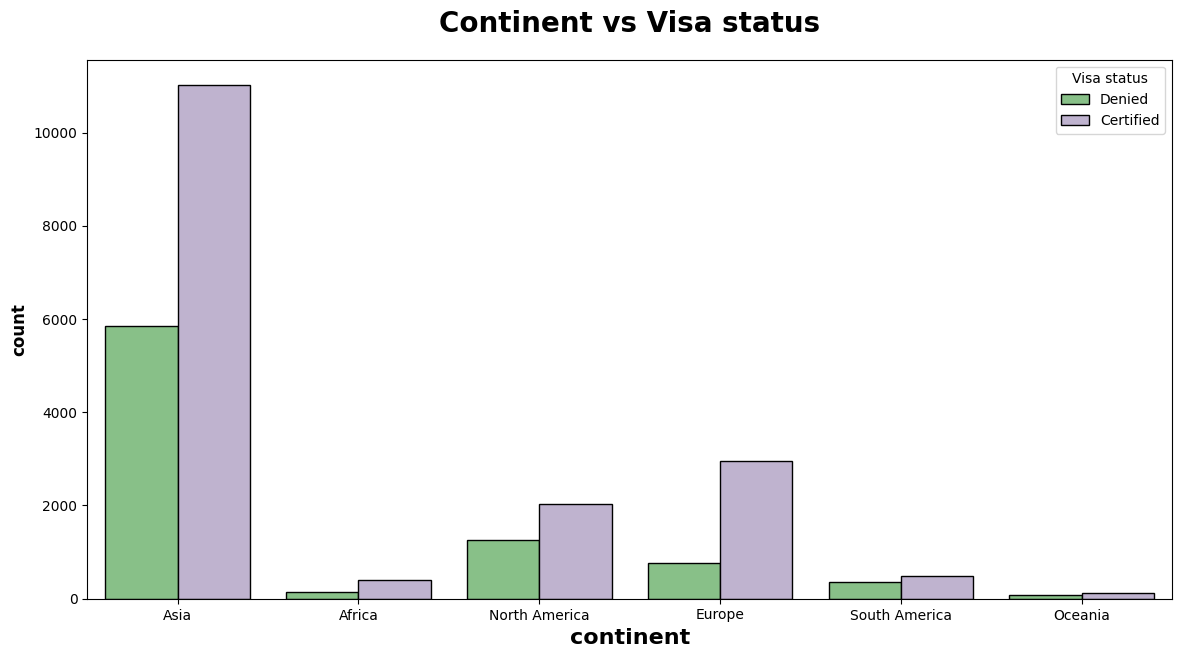

In [19]:
plt.subplots(figsize=(14,7))
sns.countplot(x='continent',hue='case_status',data=df,ec='black',palette='Accent')
plt.title("Continent vs Visa status", weight='bold',fontsize=20,pad=20)
plt.xlabel("continent",weight='bold',fontsize=16)
plt.ylabel("count",weight='bold',fontsize=12)
plt.legend(title='Visa status',fancybox=True)
plt.show()

In [20]:
df2 = df.copy()

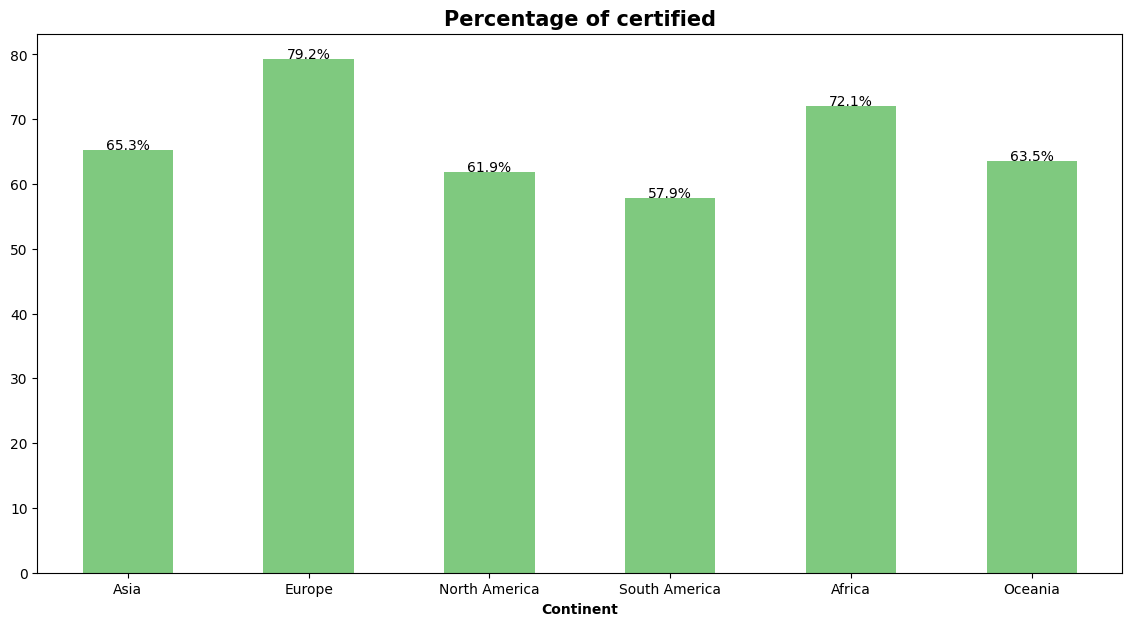

In [21]:
plt.figure(figsize=[14,7])
(100*df2[df2["case_status"].isin(["Certified"])]['continent'].value_counts()/df2['continent'].value_counts()).plot(
    kind='bar',stacked=True,colormap='Accent')
plt.title("Percentage of certified",fontsize=15,fontweight='bold')
order1 =(100*df2[df2["case_status"].isin(["Certified"])]['continent'].value_counts()/df2['continent'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt= '{:0.1f}%'.format(count)
    plt.text(n,count+0.1,strt,ha='center')

plt.xlabel('Continent', fontweight='bold')
plt.xticks(rotation=0)
plt.show()


In [22]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [23]:
df.groupby('education_of_employee')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
education_of_employee case_status            
Bachelor's            Certified     62.214188
                      Denied        37.785812
Doctorate             Certified     87.226277
                      Denied        12.773723
High School           Denied        65.964912
                      Certified     34.035088
Master's              Certified     78.627777
                      Denied        21.372223

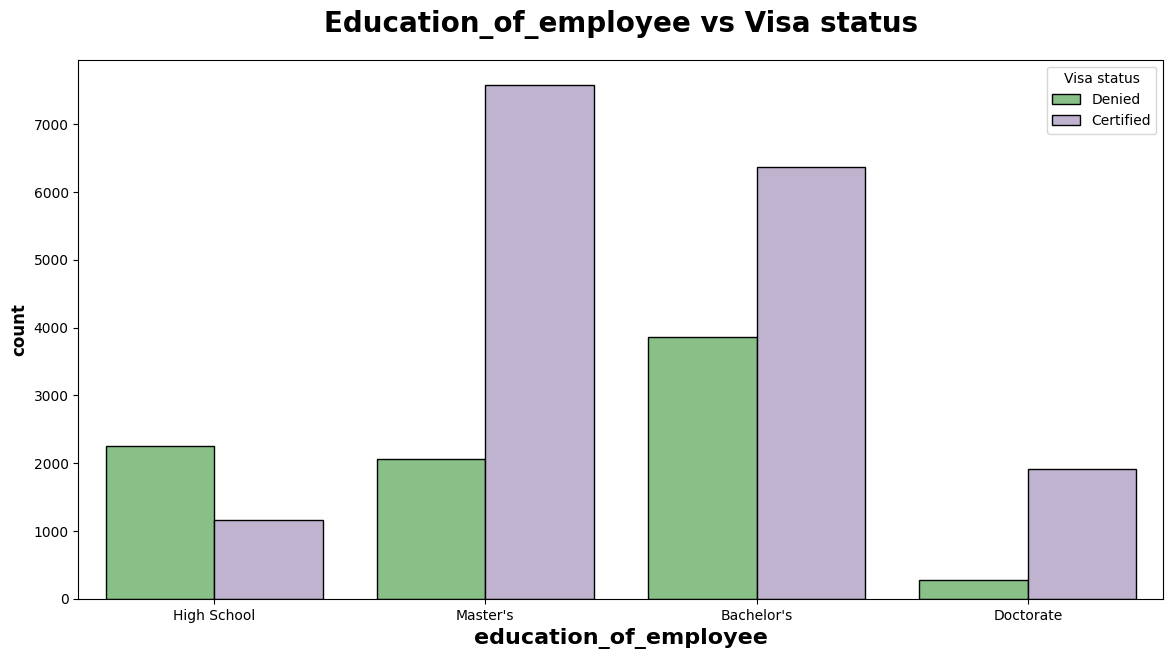

In [24]:
plt.subplots(figsize=(14,7))
sns.countplot(x='education_of_employee',hue='case_status',data=df,ec='black',palette='Accent')
plt.title("Education_of_employee vs Visa status", weight='bold',fontsize=20,pad=20)
plt.xlabel("education_of_employee",weight='bold',fontsize=16)
plt.ylabel("count",weight='bold',fontsize=12)
plt.legend(title='Visa status',fancybox=True)
plt.show()

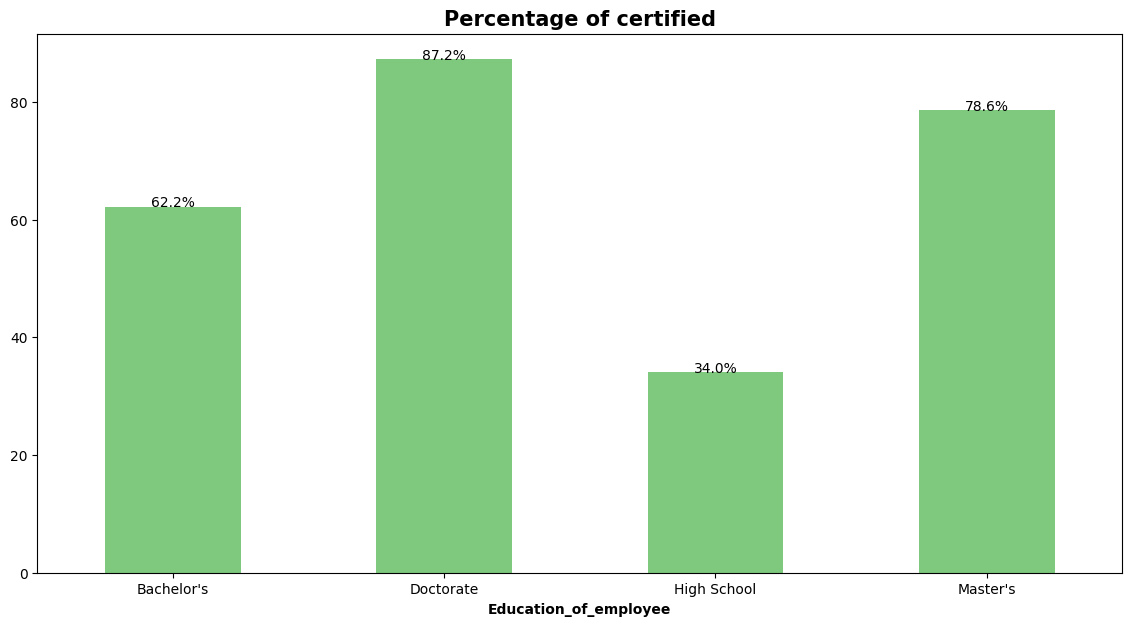

In [38]:
plt.figure(figsize=[14,7])
(100*df2[df2["case_status"].isin(["Certified"])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts()).plot(
    kind='bar',stacked=True,colormap='Accent')
plt.title("Percentage of certified",fontsize=15,fontweight='bold')
order1 =(100*df2[df2["case_status"].isin(["Certified"])]['education_of_employee'].value_counts()/df2['education_of_employee'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt= '{:0.1f}%'.format(count)
    plt.text(n,count,strt,ha='center')

plt.xlabel('Education_of_employee', fontweight='bold')
plt.xticks(rotation=0)
plt.show()


In [31]:
order1

education_of_employee
Bachelor's     62.214188
Doctorate      87.226277
High School    34.035088
Master's       78.627777
Name: count, dtype: float64

In [26]:
df.groupby('has_job_experience')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
has_job_experience case_status            
N                  Certified     56.134108
                   Denied        43.865892
Y                  Certified     74.476422
                   Denied        25.523578

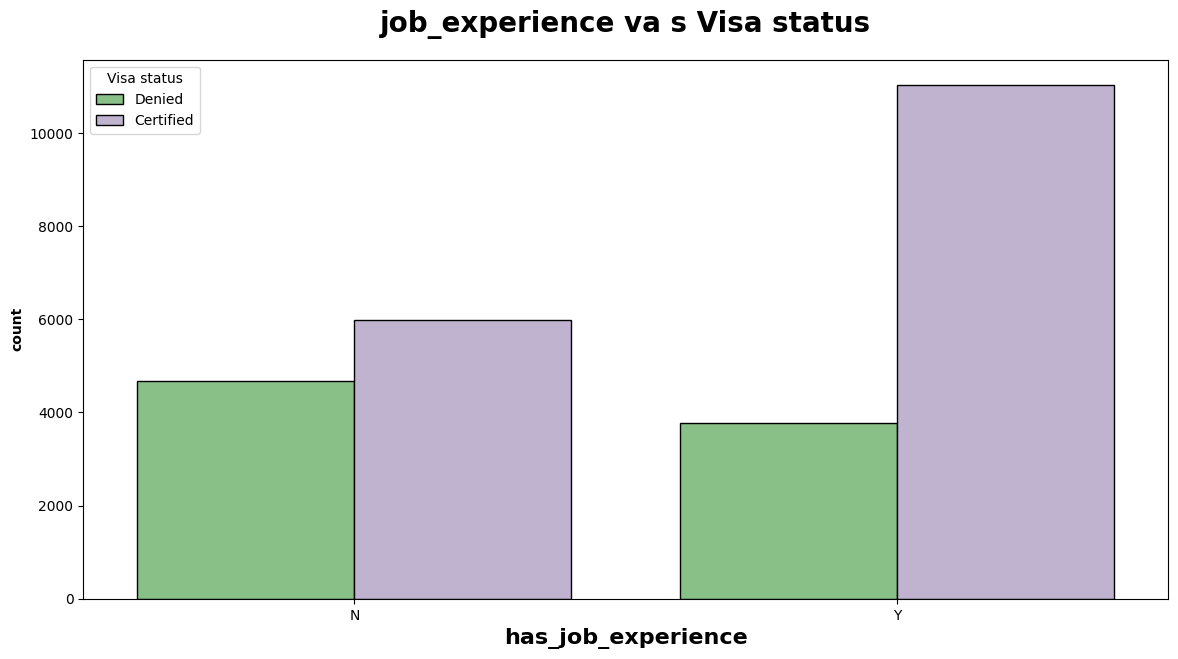

In [44]:
plt.subplots(figsize=(14,7))
sns.countplot(x='has_job_experience',hue='case_status',data=df,ec='black',palette='Accent')
plt.title("job_experience va s Visa status",fontsize=20,weight='bold',pad=20)
plt.xlabel('has_job_experience',fontsize=16,weight='bold')
plt.ylabel('count',fontsize=10,weight='bold')
plt.legend(title='Visa status',fancybox=True)

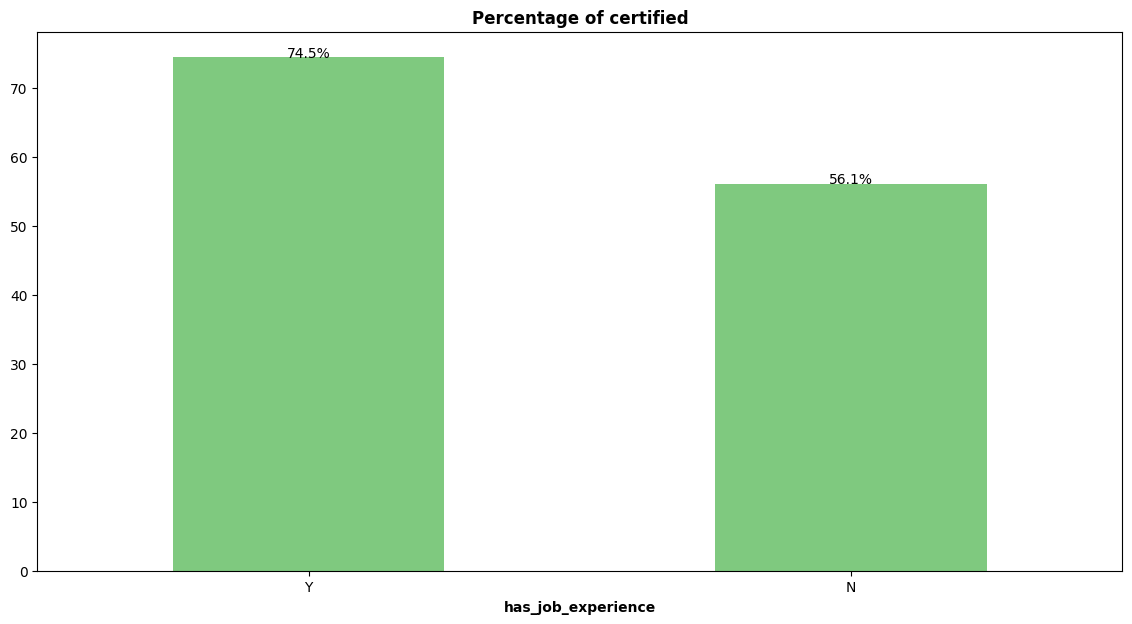

In [41]:
plt.figure(figsize=[14,7])
(100*df2[df2['case_status'].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts()).plot(
    kind='bar',stacked=True,colormap='Accent'
)
plt.title("Percentage of certified",fontsize=12,weight='bold')
order1 = (100*df2[df2['case_status'].isin(['Certified'])]['has_job_experience'].value_counts()/df2['has_job_experience'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt= '{:0.1f}%'.format(count)
    plt.text(n,count,strt,ha='center')

plt.xlabel('has_job_experience', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

In [42]:
df.groupby('requires_job_training')['case_status'].value_counts(normalize=True).to_frame()*100

proportion
requires_job_training case_status            
N                     Certified     66.645949
                      Denied        33.354051
Y                     Certified     67.884941
                      Denied        32.115059

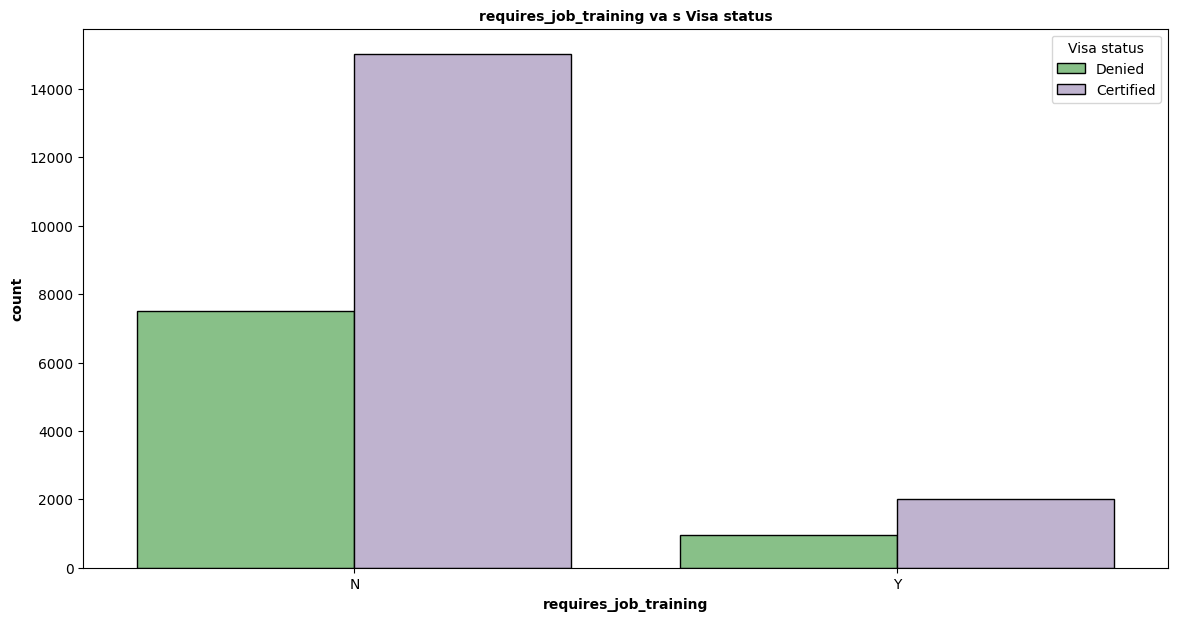

In [45]:
plt.subplots(figsize=(14,7))
sns.countplot(x='requires_job_training',hue='case_status',data=df,ec='black',palette='Accent')
plt.title("requires_job_training va s Visa status",fontsize=10,weight='bold')
plt.xlabel('requires_job_training',fontsize=10,weight='bold')
plt.ylabel('count',fontsize=10,weight='bold')
plt.legend(title='Visa status',fancybox=True)

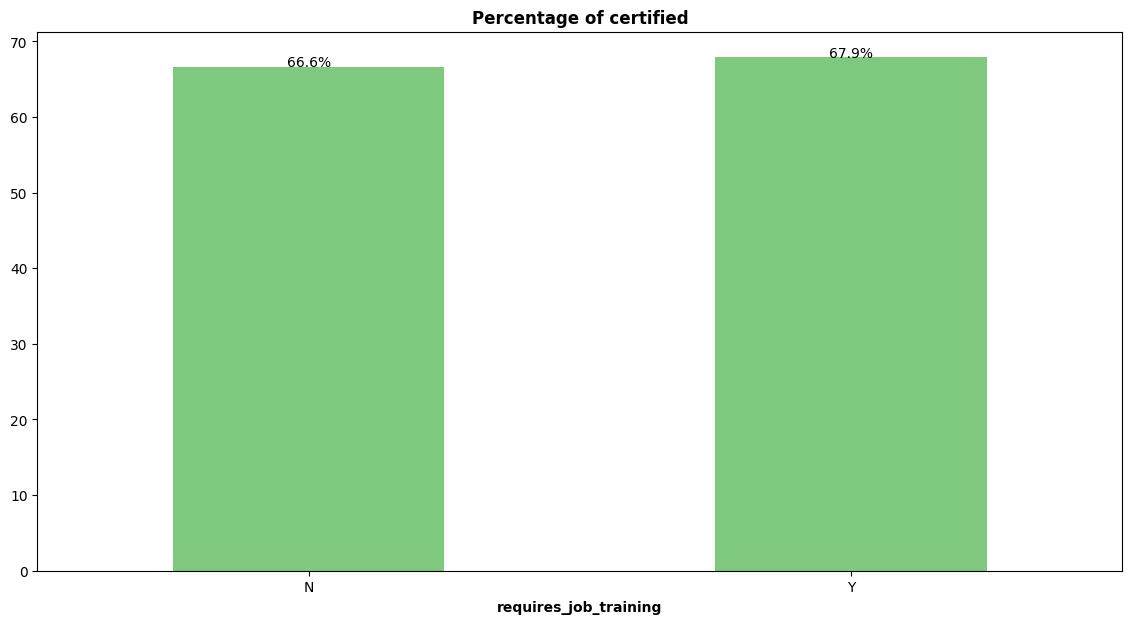

In [46]:
plt.figure(figsize=[14,7])
(100*df2[df2['case_status'].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts()).plot(
    kind='bar',stacked=True,colormap='Accent'
)
plt.title("Percentage of certified",fontsize=12,weight='bold')
order1 = (100*df2[df2['case_status'].isin(['Certified'])]['requires_job_training'].value_counts()/df2['requires_job_training'].value_counts())
for n in range(order1.shape[0]):
    count = order1[n]
    strt= '{:0.1f}%'.format(count)
    plt.text(n,count,strt,ha='center')

plt.xlabel('requires_job_training', fontweight='bold')
plt.xticks(rotation=0)
plt.show()

(-38162.82257946424, 639459.128806203)

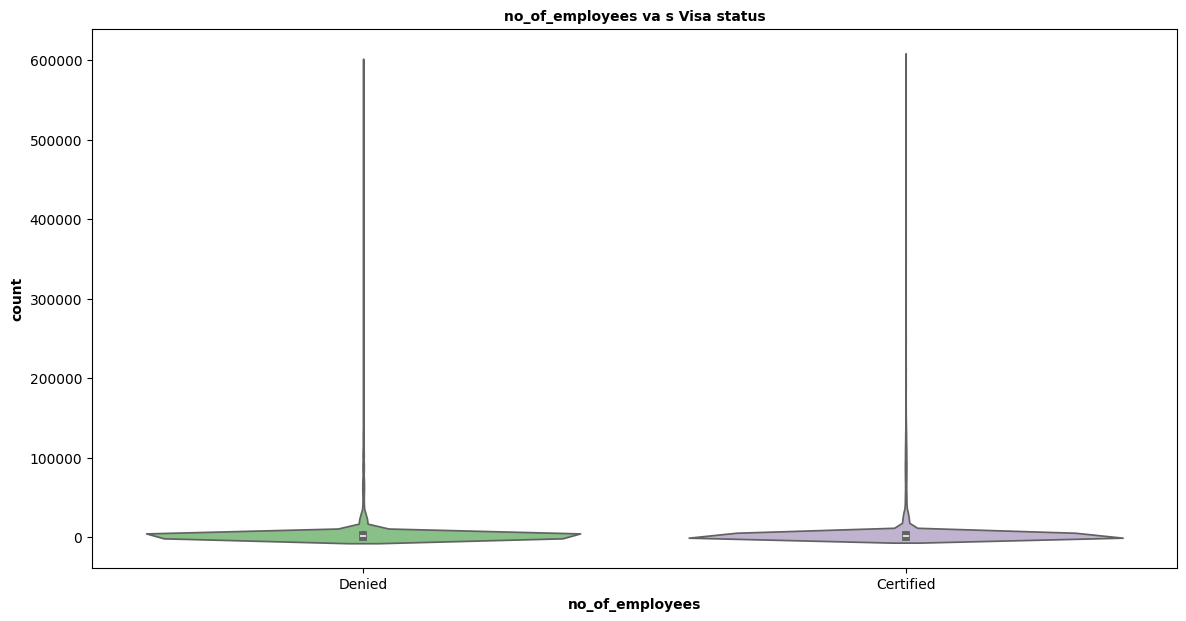

In [47]:
plt.subplots(figsize=(14,7))
sns.violinplot(x='case_status',y='no_of_employees',data=df,palette='Accent')
plt.title("no_of_employees va s Visa status",fontsize=10,weight='bold')
plt.xlabel('no_of_employees',fontsize=10,weight='bold')
plt.ylabel('count',fontsize=10,weight='bold')
plt.ylim()